# Credit Card Risk Analysis

This project analyzes and models real, anonymized credit card transactions
to detect potential fraud, using the well-known ULB Machine Learning Group
credit card fraud dataset (Worldline / Universite Libre de Bruxelles).

**Dataset:** 284,807 transactions made by European cardholders over two
days in September 2013, with only 492 labeled as fraudulent (0.172% of
all transactions) -- a genuinely, severely imbalanced real-world dataset.
Features V1-V28 are PCA-transformed components (original features are
confidential and cannot be released); `Time` and `Amount` are the only
untransformed features. `Class` is the target: 0 = legitimate,
1 = fraudulent.

**Goal:** identify suspicious transactions while minimizing false
positives -- the central tension in any fraud system, since flagging too
aggressively creates customer friction and support cost, while flagging
too conservatively lets real fraud through.

**Structure**
1. Data exploration
2. Data preprocessing
3. Modeling & evaluation (Logistic Regression, Decision Tree, Random Forest)
4. Handling class imbalance with SMOTE
5. Precision-recall tradeoff analysis
6. Results, model comparison & recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report
)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 35)


## 1. Data Exploration

In [2]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Distribution of classes

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


/tmp/ipykernel_651/3058062128.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[0], palette=["#3b82f6", "#ef4444"])


/tmp/ipykernel_651/3058062128.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
/tmp/ipykernel_651/3058062128.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[1], palette=["#3b82f6", "#ef4444"])


/tmp/ipykernel_651/3058062128.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Legitimate (0)", "Fraud (1)"])


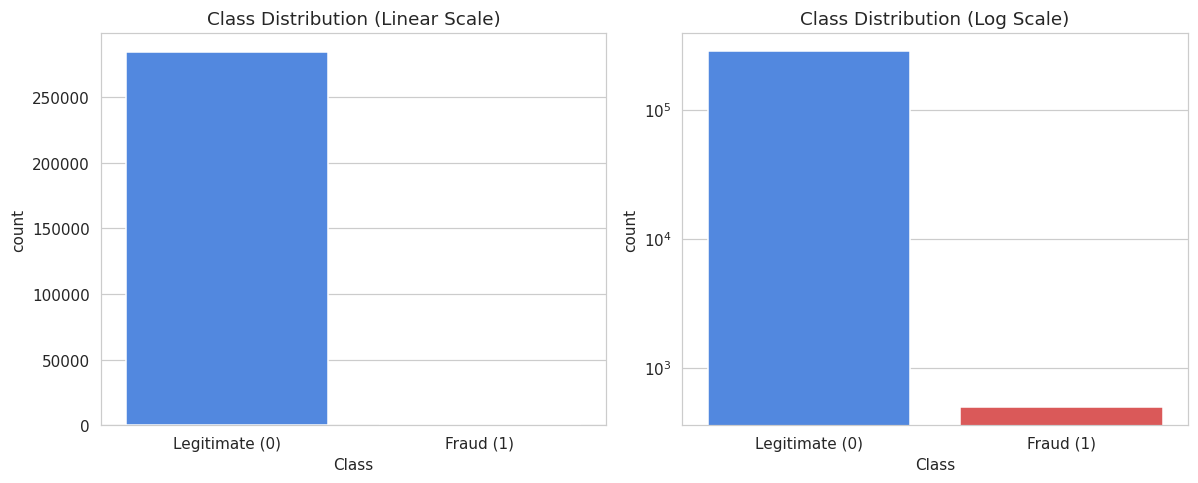

In [5]:
print(df["Class"].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x="Class", data=df, ax=axes[0], palette=["#3b82f6", "#ef4444"])
axes[0].set_title("Class Distribution (Linear Scale)")
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])

sns.countplot(x="Class", data=df, ax=axes[1], palette=["#3b82f6", "#ef4444"])
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)")
axes[1].set_xticklabels(["Legitimate (0)", "Fraud (1)"])
plt.tight_layout()
plt.savefig("outputs_class_distribution.png")
plt.show()


**Identifying the imbalance issue:** fraud accounts for only 0.173%
of transactions -- 492 out of 284,807. This is severe enough that a model
predicting "never fraud" would already be 99.83% accurate while being
completely useless, which is why accuracy alone cannot be the evaluation
metric for this problem (this is revisited in Section 3).

### Missing values

In [6]:
print(df.isnull().sum().sum(), "total missing values across the dataset")


0 total missing values across the dataset


### Correlation between features

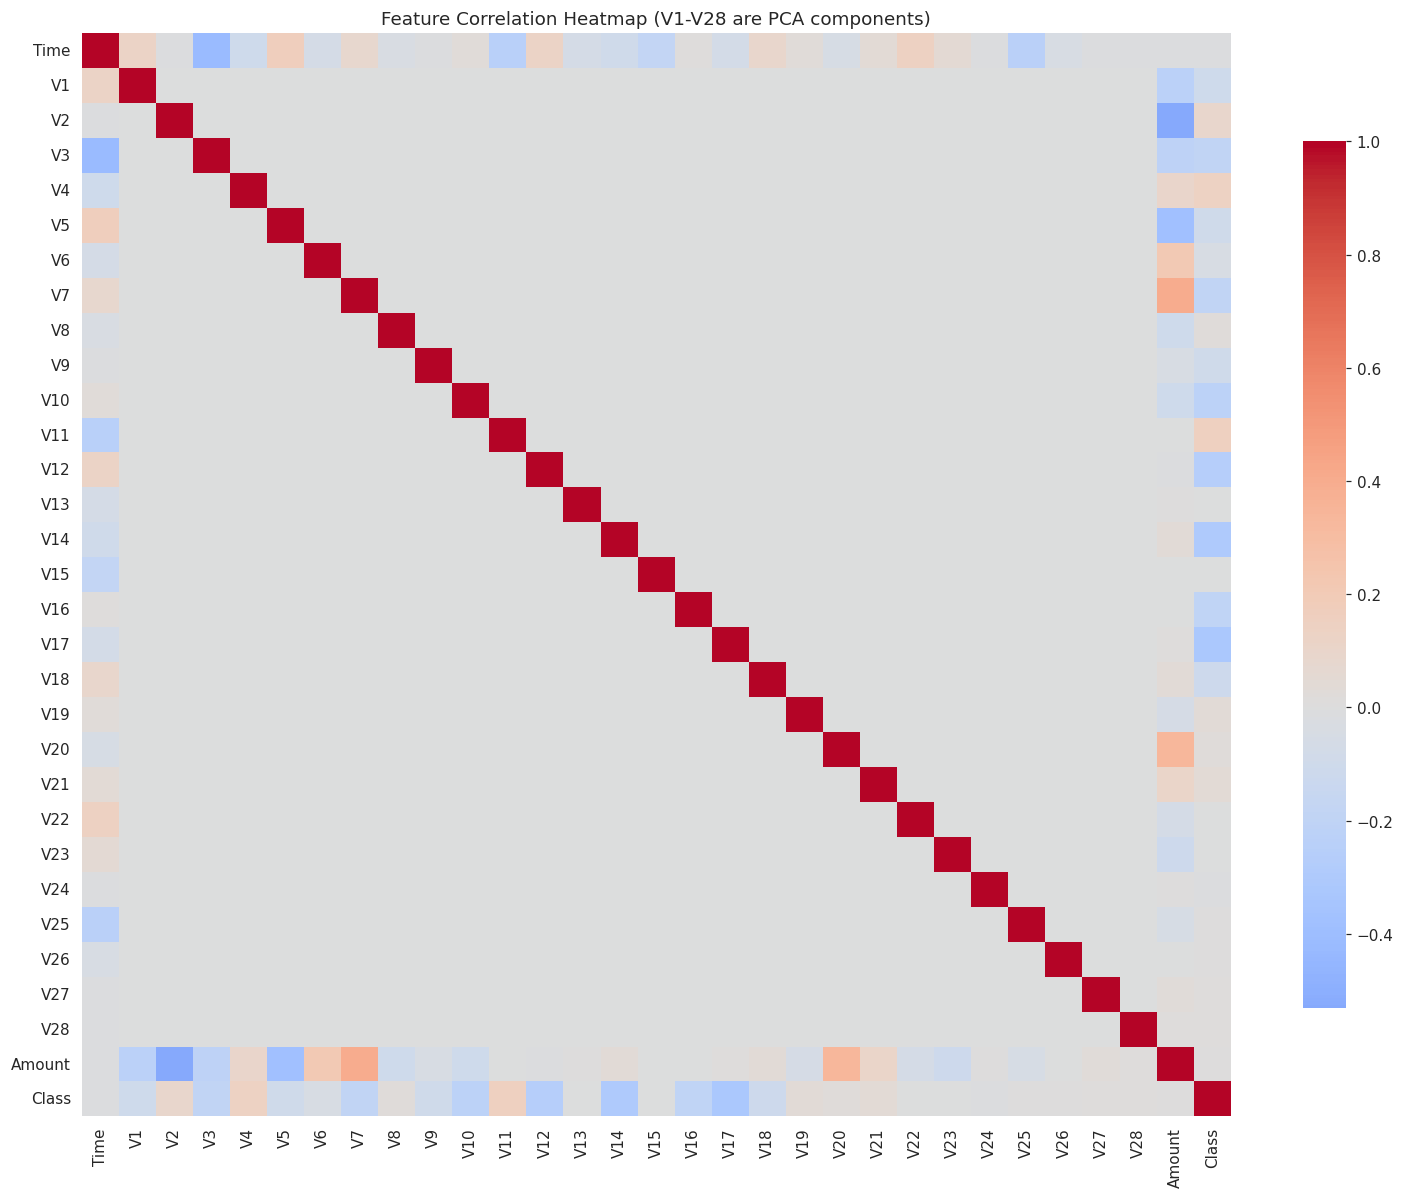

In [7]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap (V1-V28 are PCA components)")
plt.tight_layout()
plt.savefig("outputs_correlation_heatmap.png")
plt.show()


In [8]:
# Which features correlate most strongly with the fraud label itself?
class_corr = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
class_corr.head(10)


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64

**Correlation takeaway:** because V1-V28 are already PCA components,
they're close to uncorrelated with each other by construction -- the more
useful signal is which components correlate most with `Class` itself.
A handful of components (notably V17, V14, V12, V10 in this dataset)
stand out as the strongest linear signals, though tree-based models below
can also pick up non-linear patterns a correlation coefficient would miss.

### Amount distribution: legitimate vs. fraudulent transactions

/tmp/ipykernel_651/2086261137.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legitimate", "Fraud"])


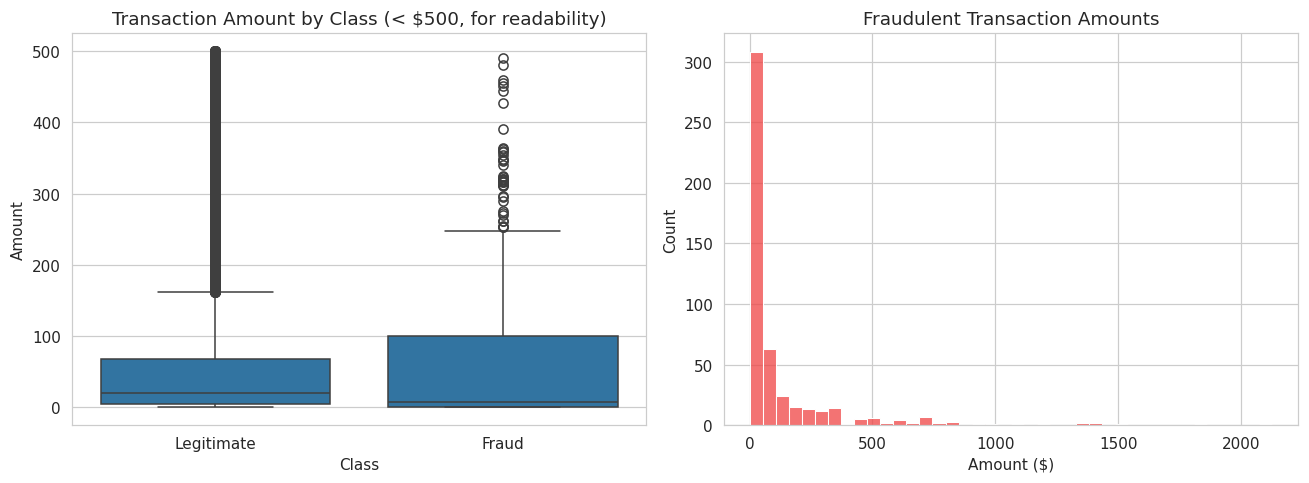

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], ax=axes[0])
axes[0].set_title("Transaction Amount by Class (< $500, for readability)")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.histplot(df[df["Class"] == 1]["Amount"], bins=40, ax=axes[1], color="#ef4444")
axes[1].set_title("Fraudulent Transaction Amounts")
axes[1].set_xlabel("Amount ($)")
plt.tight_layout()
plt.savefig("outputs_amount_distribution.png")
plt.show()


In [10]:
print("Legitimate transaction amount summary:")
print(df[df.Class == 0]["Amount"].describe())
print("\nFraudulent transaction amount summary:")
print(df[df.Class == 1]["Amount"].describe())


Legitimate transaction amount summary:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transaction amount summary:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


**Amount takeaway:** fraudulent transactions skew toward smaller
amounts on average, but with real variation -- Amount alone is a weak
signal, consistent with why this dataset relies on the PCA-transformed
behavioral features rather than transaction size to distinguish fraud.

## 2. Data Preprocessing

No missing values exist in this dataset (confirmed above), so preprocessing
here is about scaling and splitting, not imputation.

**A practical compute tradeoff, stated explicitly:** the full dataset
(284,807 rows) is used for all exploration above. For the modeling section
below, a stratified random subsample of 100,000 transactions is used
instead of the full dataset, preserving the exact real-world fraud rate
(0.173%) rather than artificially rebalancing it. This is purely a runtime
decision for this environment (training multiple models, including one
with SMOTE-doubled data, on 284K rows repeatedly is slow on limited
compute) -- it does not change the imbalance problem being solved, and the
same code works unchanged on the full dataset given more compute time.

In [11]:
df_model, _ = train_test_split(
    df, train_size=100_000, stratify=df["Class"], random_state=42
)
print("Modeling subsample shape:", df_model.shape)
print(f"Fraud rate in subsample: {df_model['Class'].mean()*100:.3f}% (full data: {df['Class'].mean()*100:.3f}%)")


Modeling subsample shape: (100000, 31)
Fraud rate in subsample: 0.173% (full data: 0.173%)


In [12]:
# V1-V28 are already PCA components on a comparable scale. Time and Amount
# are the only raw, unscaled features, so only those two need scaling.
scaler = StandardScaler()
df_model = df_model.copy()
df_model["Time_scaled"] = scaler.fit_transform(df_model[["Time"]])
df_model["Amount_scaled"] = scaler.fit_transform(df_model[["Amount"]])

feature_cols = [c for c in df_model.columns if c not in ["Time", "Amount", "Class"]]
X = df_model[feature_cols]
y = df_model["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(f"Fraud rate -- train: {y_train.mean()*100:.3f}%, test: {y_test.mean()*100:.3f}%")


(80000, 30) (20000, 30)
Fraud rate -- train: 0.172%, test: 0.175%


**Why stratify the split:** with fraud at 0.17% of the data, a plain
random split risks leaving the test set with too few (or too many) fraud
cases to evaluate reliably. Stratifying guarantees both sets keep the same
fraud rate as the full dataset.

## 3. Modeling & Evaluation

Three models are trained on the **original, imbalanced** training data
first, to establish honest baselines before any resampling technique is
introduced. A shared evaluation function is used throughout so every model
is judged the same way.

In [13]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    }, y_pred, y_prob

results = []
predictions = {}


### Logistic Regression (baseline)

In [14]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)

res, y_pred, y_prob = evaluate_model("Logistic Regression", log_reg, X_test, y_test)
results.append(res)
predictions["Logistic Regression"] = (y_pred, y_prob)
res


{'Model': 'Logistic Regression',
 'Accuracy': 0.9775,
 'Precision': 0.0594,
 'Recall': 0.8,
 'F1': 0.1107,
 'ROC-AUC': 0.95}

### Decision Tree

In [15]:
dt = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

res, y_pred, y_prob = evaluate_model("Decision Tree", dt, X_test, y_test)
results.append(res)
predictions["Decision Tree"] = (y_pred, y_prob)
res


{'Model': 'Decision Tree',
 'Accuracy': 0.9949,
 'Precision': 0.2185,
 'Recall': 0.7429,
 'F1': 0.3377,
 'ROC-AUC': 0.8706}

### Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight="balanced_subsample",
    random_state=42
)
rf.fit(X_train, y_train)

res, y_pred, y_prob = evaluate_model("Random Forest", rf, X_test, y_test)
results.append(res)
predictions["Random Forest"] = (y_pred, y_prob)
res


{'Model': 'Random Forest',
 'Accuracy': 0.9992,
 'Precision': 0.8065,
 'Recall': 0.7143,
 'F1': 0.7576,
 'ROC-AUC': 0.8859}

### Comparing all three models so far

In [17]:
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9775,0.0594,0.8000,0.1107,0.9500
1,Decision Tree,0.9949,0.2185,0.7429,0.3377,0.8706
2,Random Forest,0.9992,0.8065,0.7143,0.7576,0.8859


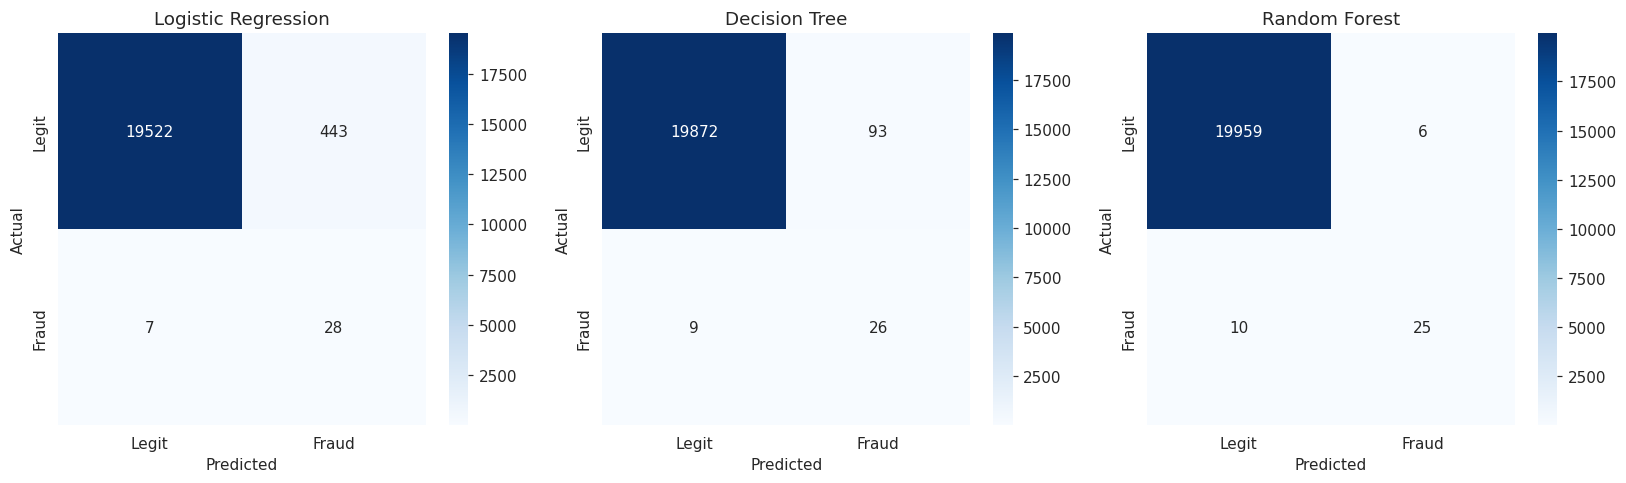

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, (y_pred, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs_confusion_matrices.png")
plt.show()


**Why accuracy is a misleading headline metric here:** all three
models will show very high accuracy simply because 99.83% of transactions
are legitimate -- a model could get that accuracy without ever correctly
flagging fraud. Precision and recall on the fraud class (1) are what
actually matter: recall tells you what share of real fraud gets caught,
precision tells you how much you can trust a "fraud" flag before
investigating it further.

## 4. Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic
fraud examples in the training set by interpolating between real fraud
cases' nearest neighbors, rather than simply duplicating them. This is
applied to the **training set only** -- applying it before the train/test
split would leak synthetic information into the test set and produce an
overly optimistic, invalid evaluation.

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 79862, 1: 138}
After SMOTE:  {0: 79862, 1: 79862}


In [20]:
rf_smote = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)

res, y_pred, y_prob = evaluate_model("Random Forest + SMOTE", rf_smote, X_test, y_test)
results.append(res)
predictions["Random Forest + SMOTE"] = (y_pred, y_prob)
res


{'Model': 'Random Forest + SMOTE',
 'Accuracy': 0.9985,
 'Precision': 0.551,
 'Recall': 0.7714,
 'F1': 0.6429,
 'ROC-AUC': 0.9626}

In [21]:
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9775,0.0594,0.8000,0.1107,0.9500
1,Decision Tree,0.9949,0.2185,0.7429,0.3377,0.8706
2,Random Forest,0.9992,0.8065,0.7143,0.7576,0.8859
3,Random Forest + SMOTE,0.9985,0.5510,0.7714,0.6429,0.9626


**SMOTE takeaway:** compare this row to the plain Random Forest
above -- whether SMOTE actually helps here (versus `class_weight` alone,
already used in the earlier models) is exactly the kind of empirical
question you should check rather than assume; both are legitimate
imbalance-handling techniques and the better one can depend on the
dataset.

## 5. Precision-Recall Tradeoff

With this level of class imbalance, the ROC curve can look deceptively
good even for a mediocre model (because true negatives are so easy to get
right). The **precision-recall curve** is the more honest picture for
imbalanced problems, and this section makes the precision/recall tradeoff
explicit and adjustable via the decision threshold.

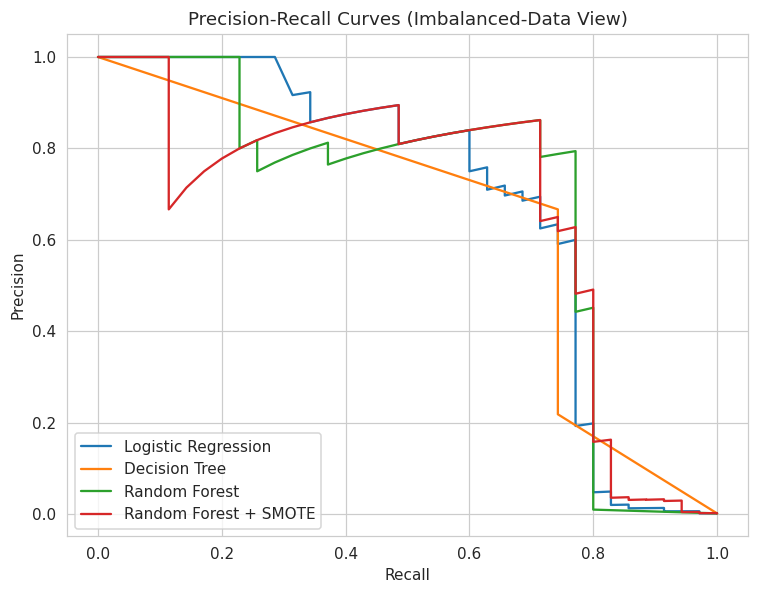

In [22]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, (_, y_prob) in predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(recall, precision, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (Imbalanced-Data View)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_precision_recall_curve.png")
plt.show()


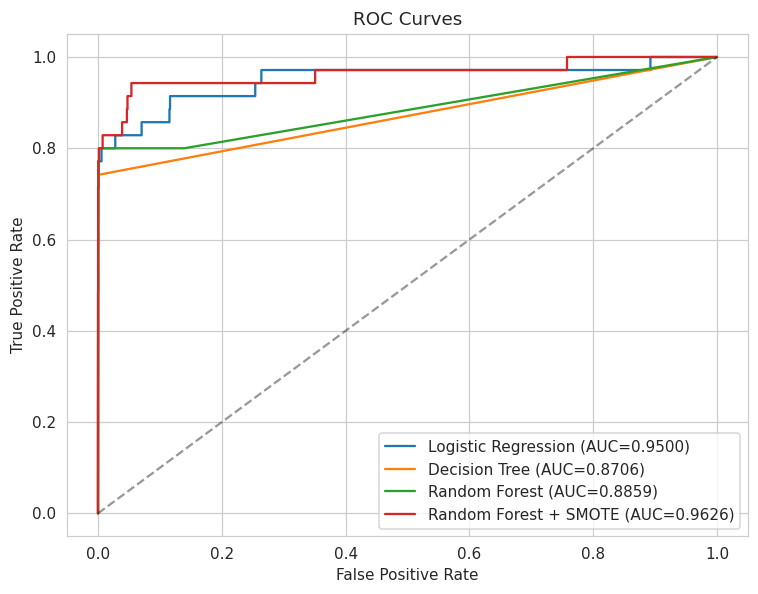

In [23]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, (_, y_prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_roc_curve.png")
plt.show()


In [24]:
# Showing the tradeoff concretely: what happens to precision and recall
# at different decision thresholds for the best-performing model?
best_model_name = results_df.sort_values("F1", ascending=False).iloc[0]["Model"]
_, y_prob_best = predictions[best_model_name]

thresholds_to_check = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_rows = []
for t in thresholds_to_check:
    y_pred_t = (y_prob_best >= t).astype(int)
    threshold_rows.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, y_pred_t), 3),
        "Recall": round(recall_score(y_test, y_pred_t), 3),
        "F1": round(f1_score(y_test, y_pred_t), 3),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(f"Threshold sweep for: {best_model_name}")
threshold_df


Threshold sweep for: Random Forest


,Threshold,Precision,Recall,F1
0,0.2,0.730,0.771,0.750
1,0.3,0.788,0.743,0.765
2,0.4,0.781,0.714,0.746
3,0.5,0.806,0.714,0.758
4,0.6,0.862,0.714,0.781
5,0.7,0.857,0.686,0.762
6,0.8,0.833,0.571,0.678


**Threshold tradeoff takeaway:** lowering the decision threshold
catches more fraud (higher recall) at the cost of more false alarms (lower
precision). Which threshold is "right" isn't a modeling question -- it's a
business one, depending on the relative cost of missing fraud versus the
cost/friction of a false alarm (e.g. blocking a legitimate customer's
card). This table is what you'd actually bring to that conversation.

## 6. Results & Insights

### Full model comparison

In [25]:
results_df.sort_values("F1", ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9992,0.8065,0.7143,0.7576,0.8859
1,Random Forest + SMOTE,0.9985,0.5510,0.7714,0.6429,0.9626
2,Decision Tree,0.9949,0.2185,0.7429,0.3377,0.8706
3,Logistic Regression,0.9775,0.0594,0.8000,0.1107,0.9500


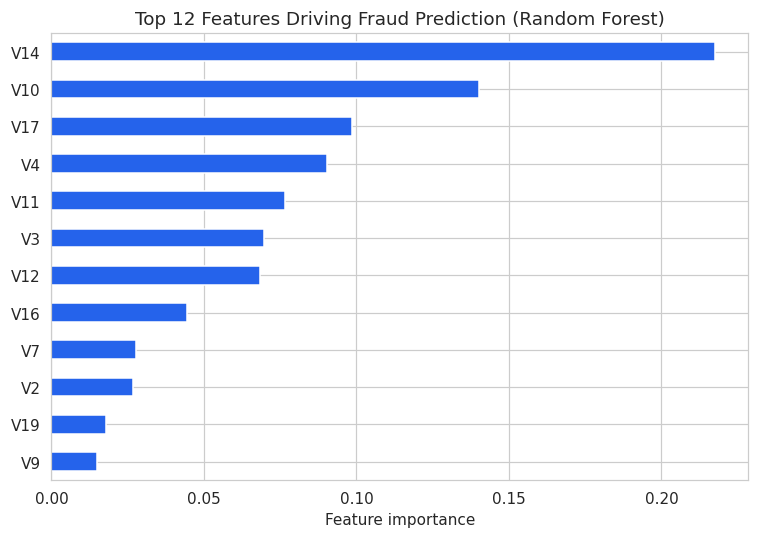

In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot.barh(ax=ax, color="#2563eb")
ax.set_title("Top 12 Features Driving Fraud Prediction (Random Forest)")
ax.set_xlabel("Feature importance")
plt.tight_layout()
plt.savefig("outputs_feature_importance.png")
plt.show()


### Recommendations for improving a real fraud detection system

1. **Choose the evaluation metric and decision threshold deliberately, not
   by default.** Accuracy is meaningless here; the threshold sweep in
   Section 5 shows precision and recall trade off directly against each
   other, and the right operating point depends on the business's real
   cost of a missed fraud versus a false alarm -- not a fixed 0.5 cutoff.
2. **Random Forest (or the SMOTE-augmented version, whichever the results
   table above ranks higher on F1/recall) is the strongest candidate of
   the three tested**, but Logistic Regression remains valuable as an
   interpretable baseline and a fast, lightweight fallback.
3. **Investigate the top features driving predictions** (the PCA
   components ranked above) with the data provider, where possible, to
   understand what real-world behavior they represent -- the confidential/
   PCA-transformed nature of this dataset limits how actionable individual
   feature insights can be, which is a genuine limitation worth naming
   rather than glossing over.
4. **In production, this should be a probability-ranked queue, not a
   binary flag.** Feeding `predict_proba` scores into a review queue lets
   a fraud team prioritize the highest-risk transactions first rather than
   treating every flagged transaction as equally urgent.
5. **Re-evaluate regularly.** Fraud patterns shift over time (concept
   drift); a model trained on a two-day window from 2013, as this dataset
   is, would need retraining on current data before any real deployment,
   not just a one-time fit.
